# Ariadne NYC pedestrian graph pipeline

This notebook is the audit trail for the graph that powers Ariadne's offline routing in NYC. It ingests six public datasets, conforms them to the OpenSidewalks v0.3 schema, and emits two artifacts: `output/nyc.graphml` (the canonical attributed graph as XML) and `output/nyc-pedestrian.bin` (the packed binary the in-browser WASM router consumes). Every attribute in the final graph traces back to a source listed below.

In [1]:
from __future__ import annotations

import hashlib
import json
from pathlib import Path

import geopandas as gpd
import networkx as nx
import numpy as np
import pandas as pd
import yaml
from shapely.geometry import shape

REPO   = Path.cwd()
RAW    = REPO / "data" / "raw"
CLEAN  = REPO / "data" / "clean"
STAGED = REPO / "data" / "staged"
OUT    = REPO / "output"

with open(REPO / "config" / "sources.yaml") as f:
    SOURCES = yaml.safe_load(f)["sources"]
with open(REPO / "config" / "build.yaml") as f:
    BUILD = yaml.safe_load(f)

## Inputs

Six sources. The fetcher in `pipeline/stages/acquire.py` writes a SHA-256 of every download into `data/raw/manifest.json`, so this manifest is reproducible: rerunning the build against the same upstream snapshots yields identical hashes.

In [2]:
INPUTS = {
    "osm_walk": {
        "name":   "OpenStreetMap pedestrian-tagged ways (NYC bbox)",
        "url":    "https://www.openstreetmap.org/copyright",
        "format": "OSMnx graph -> GeoJSON LineStrings",
        "license": "ODbL-1.0",
    },
    "nyc_planimetric_sidewalks": {
        "name":   "NYC Planimetric Database, sidewalk polygons (OTI)",
        "url":    "https://data.cityofnewyork.us/City-Government/NYC-Planimetric-Database-Sidewalk/52n9-sdep",
        "format": "Socrata GeoJSON Polygon",
        "license": "Public Domain (NYC Open Data)",
    },
    "nyc_dot_ramps": {
        "name":   "NYC DOT Pedestrian Ramp Locations (curb cuts)",
        "url":    "https://data.cityofnewyork.us/Transportation/Pedestrian-Ramp-Locations/ufzp-rrqu",
        "format": "Socrata GeoJSON Point",
        "license": "Public Domain (NYC Open Data)",
    },
    "nyc_boroughs": {
        "name":   "NYC Borough Boundaries",
        "url":    "https://data.cityofnewyork.us/City-Government/Borough-Boundaries/7t3b-ywvw",
        "format": "Socrata GeoJSON MultiPolygon",
        "license": "Public Domain (NYC Open Data)",
    },
    "dem_nyc": {
        "name":   "NYC 2017 1ft LiDAR bare-earth DTM (NYS GIS ImageServer)",
        "url":    "https://elevation.its.ny.gov/arcgis/rest/services/NYC_TopoBathymetric_2017_1_meter/ImageServer",
        "format": "GeoTIFF, one tile per borough",
        "license": "Public Domain (NY State)",
    },
    "mta_ada_stations": {
        "name":   "MTA Subway Stations w/ ADA flag",
        "url":    "https://data.cityofnewyork.us/resource/drh3-e2fd.json",
        "format": "Socrata GeoJSON Point",
        "license": "Public Domain (MTA)",
    },
}

with open(RAW / "manifest.json") as f:
    fetched = json.load(f)

rows = []
for sid, meta in INPUTS.items():
    fm = fetched.get(sid, {})
    rows.append({
        "source":       sid,
        "description":  meta["name"],
        "format":       meta["format"],
        "license":      meta["license"],
        "fetched_on":   fm.get("retrieved_at", "")[:10],
        "row_count":    fm.get("row_count", 0),
        "sha256_8":     (fm.get("content_hash") or "")[:8],
    })
manifest_df = pd.DataFrame(rows)
manifest_df

,source,description,format,license,fetched_on,row_count,sha256_8
0,osm_walk,OpenStreetMap pedestrian-tagged ways (NYC bbox),OSMnx graph -> GeoJSON LineStrings,ODbL-1.0,2026-04-25,2603620,9143a2d3
1,nyc_planimetric_sidewalks,"NYC Planimetric Database, sidewalk polygons (OTI)",Socrata GeoJSON Polygon,Public Domain (NYC Open Data),2026-04-25,50865,585e6420
2,nyc_dot_ramps,NYC DOT Pedestrian Ramp Locations (curb cuts),Socrata GeoJSON Point,Public Domain (NYC Open Data),2026-04-25,217679,5c4a4237
3,nyc_boroughs,NYC Borough Boundaries,Socrata GeoJSON MultiPolygon,Public Domain (NYC Open Data),2026-04-25,5,90fcece0
4,dem_nyc,NYC 2017 1ft LiDAR bare-earth DTM (NYS GIS Ima...,"GeoTIFF, one tile per borough",Public Domain (NY State),2026-04-25,0,7bc2956d
5,mta_ada_stations,MTA Subway Stations w/ ADA flag,Socrata GeoJSON Point,Public Domain (MTA),2026-04-25,1488,561ea5cc


## Load

Files are read from `data/raw/`. The fetcher has already deduplicated and chunked them; this cell just confirms what made it onto disk and reports CRS and feature counts.

In [3]:
boroughs   = gpd.read_file(RAW / "nyc_boroughs"             / "boroughs.geojson")
ramps      = gpd.read_file(RAW / "nyc_dot_ramps"            / "nyc_dot_ramps.geojson")
planimetric= gpd.read_file(RAW / "nyc_planimetric_sidewalks"/ "nyc_planimetric_sidewalks.geojson")
ada        = gpd.read_file(RAW / "mta_ada_stations"         / "mta_ada_stations.geojson")

for label, gdf in [
    ("boroughs",    boroughs),
    ("curb ramps",  ramps),
    ("planimetric sidewalks", planimetric),
    ("MTA stations", ada),
]:
    print(f"  {label:24s}  {len(gdf):>9,} features   CRS {gdf.crs}")

osm_path = RAW / "osm_walk" / "osm_edges.geojson"
print(f"  {'osm_walk (on disk)':24s}  {osm_path.stat().st_size / 1e9:>5.2f} GB   (loaded lazily by stage 2)")

  boroughs                          5 features   CRS EPSG:4326
  curb ramps                  217,679 features   CRS EPSG:4326
  planimetric sidewalks        50,865 features   CRS EPSG:4326
  MTA stations                  1,488 features   CRS EPSG:4326
  osm_walk (on disk)         1.82 GB   (loaded lazily by stage 2)


## Reproject

All metric operations (snap tolerance, polygon centerline derivation, edge length) run in EPSG:32618, UTM Zone 18N, metres. UTM 18N covers the whole city without splitting Staten Island, and it's a standard ESRI/PROJ identifier so downstream consumers don't need a custom datum file. The published artifacts are reprojected back to EPSG:4326 for portability.

In [4]:
boroughs_m = boroughs.to_crs("EPSG:32618")
boroughs_m = boroughs_m.assign(area_km2=boroughs_m.geometry.area / 1e6)
boroughs_m[["boro_name", "area_km2"]].sort_values("area_km2", ascending=False).reset_index(drop=True)

,boro_name,area_km2
0,Queens,465.065448
1,Staten Island,265.404884
2,Brooklyn,252.128199
3,Bronx County,148.843162
4,Manhattan,87.274323


## Clean

Stage 2 (`pipeline/stages/clean.py`) runs `make_valid` on every geometry and drops slivers under 1 m². Output goes to `data/clean/`. The cleaning report is committed alongside the artifacts.

In [5]:
print((CLEAN / "cleaning_report.md").read_text())

# Cleaning Report

Generated: 2026-04-25T05:29:05.373341+00:00

## Summary

| Source | Raw features | Dropped (geom) | Repaired (geom) | Clean features |
|--------|-------------|----------------|-----------------|----------------|
| nyc_boroughs | 5 | 0 | 0 | 5 |
| osm_walk | 2603620 | 0 | 2 | 2603620 |
| nyc_dot_ramps | 217679 | 0 | 0 | 217679 |
| nyc_planimetric_sidewalks | 50865 | 0 | 32 | 50865 |
| mta_ada_stations | 1488 | 0 | 0 | 1488 |

## Notes by Source

### nyc_boroughs
- No issues

### osm_walk
- Repaired 2 invalid geometries with make_valid()

### nyc_dot_ramps
- No issues

### nyc_planimetric_sidewalks
- Repaired 32 invalid geometries with make_valid()
- Dropped 2 slivers with area < 1 m²

### mta_ada_stations
- No issues



## Schema-map: derive OSW features

Stage 3 (`pipeline/stages/schema_map.py`) splits OSM walking edges into the four OSW classes (`Sidewalk`, `Crossing`, `Footway`, `Street`) using `highway` and `footway` tags. Where OSM has no separate sidewalk geometry, for example a residential street tagged `sidewalk=both` with no parallel footway, the centerline is derived from the planimetric polygon by Voronoi medial-axis approximation. Polygons already covered by an OSM edge within 10 m are skipped. Curb ramps become OSW `CurbPoint` nodes with `barrier=kerb, kerb=lowered`.

In [6]:
from pyogrio import read_info

staged_layers = {
    "sidewalks":  STAGED / "sidewalks.geojson",
    "crossings":  STAGED / "crossings.geojson",
    "footways":   STAGED / "footways.geojson",
    "streets":    STAGED / "streets.geojson",
    "curb_nodes": STAGED / "curb_nodes.geojson",
}

for name, path in staged_layers.items():
    info = read_info(path)
    print(f"  {name:12s}  {info['features']:>9,}  ({path.stat().st_size/1e6:>6.1f} MB)")

  sidewalks       932,830  ( 448.5 MB)


  crossings       434,002  ( 221.0 MB)


  footways        522,839  ( 240.2 MB)
  streets         679,662  ( 317.1 MB)


  curb_nodes      217,679  ( 107.2 MB)


## Assemble: topology and incline

Stage 4 unifies endpoints across sources within 2 m, snaps curb-ramp points to nearest edge endpoint within 5 m, and merges them into the corresponding `Point` node. Edge `incline` is computed by sampling the LiDAR DTM at the start and end of every edge and dividing rise by run; the result is clamped to ±1.0 (the OSW spec range) and stored as `ext:incline`.

In [7]:
print((STAGED / "topology_report.md").read_text())

# Topology Report

Generated: 2026-04-25T06:23:34.827606+00:00

## Graph Statistics

- Nodes in graph: 846,463
- Edges in graph: 946,280
- Connected components: 11,788
- Nodes in largest component: 512,917 (60.6%)
- Components ≥ 3 nodes: 3317
- Isolated/tiny components (< 3 nodes): 8471

## Component Size Distribution

| Rank | Component size |
|------|---------------|
| 1 | 512,917 |
| 2 | 131,907 |
| 3 | 71,954 |
| 4 | 16,152 |
| 5 | 11,930 |
| 6 | 5,406 |
| 7 | 4,215 |
| 8 | 1,293 |
| 9 | 1,252 |
| 10 | 1,235 |
| 11 | 1,212 |
| 12 | 1,113 |
| 13 | 1,050 |
| 14 | 965 |
| 15 | 738 |
| 16 | 725 |
| 17 | 715 |
| 18 | 677 |
| 19 | 655 |
| 20 | 550 |
| … | (11768 more) |


The graph is not a single connected component. The largest component holds 60.6% of nodes; the next two together hold another 24%. The fragmentation comes from real-world disconnects (Rikers Island, Hart Island, parkland with no surveyed sidewalks) plus OSM tagging gaps where a footway terminates one edge short of a crossing. Routing falls back to nearest-reachable when an origin sits in a small component.

## Schema conformance

Stage 5 runs the OpenSidewalks v0.3 JSON Schema (Draft 7) over a 2,000-feature random sample, plus structural integrity checks (unique IDs, edge geometry types, every `_u_id`/`_v_id` resolves to a node, curb nodes are Points, all coordinates fall inside the WGS84 bounds) over the entire feature collection. The report is regenerated on every build.

In [8]:
print((OUT / "validation_report.md").read_text())

# OSW Validation Report

Generated: 2026-04-25T06:30:26.972306+00:00

## Summary

- **Schema version targeted:** OpenSidewalks v0.3
- **Validator:** jsonschema (Draft7Validator) + structural integrity checks (JSON Schema validation on 2,000-feature sample; structural checks on all features)
- **Total features:** 3,720,895
- **Features passing all checks:** 3,720,895 (100.0%)
- **Features with at least one failure:** 0

## Results by Check Category

| Check | Failures |
|-------|---------|
| unique_id | ✅ pass |
| edge_geometry_type | ✅ pass |
| edge_node_reference | ✅ pass |
| curb_node_geometry | ✅ pass |
| wgs84_bounds | ✅ pass |
| json_schema | ✅ pass |

## Structural Conformance

All structural checks passed.

## JSON Schema Conformance

All JSON Schema checks passed (or schema not available).

## Known V1 Limitations

- No incline/slope data (requires elevation DEM, V1.1 scope)
- No accessibility condition ratings (requires field survey data, V1.1 scope)
- No APS (Accessible Pedes

## Transit accessibility sidecar

MTA station points are not part of the pedestrian graph topology. They're loaded into `data/staged/mta_ada_stations.geojson` and snapped to the nearest sidewalk node so the router can answer "is the closest station ADA-accessible." The `ada` flag is the static value from NYC Open Data as of the fetch date; live elevator outage data is consumed at query time in the browser, not baked in here.

In [9]:
stations = gpd.read_file(STAGED / "mta_ada_stations.geojson")
ada_col = next((c for c in ("ada", "ada_accessible") if c in stations.columns), None)
if ada_col is not None:
    counts = stations[ada_col].astype(str).str.lower().value_counts()
    print("MTA station ADA flag distribution:")
    for k, v in counts.items():
        print(f"  {k:10s}  {v:>4,}")
print(f"\nTotal station points: {len(stations):,}")

MTA station ADA flag distribution:
  1           1,488

Total station points: 1,488


## Sanity checks

Spot-check at 5th Ave & 42nd St: confirm the intersection has a node, the node carries a curb-ramp annotation, and the four corner crossings exist. If this fails on a future run, the pipeline has regressed somewhere upstream.

In [10]:
from shapely.geometry import Point

TARGET = Point(-73.9822, 40.7536)   # 5th Ave & W 42nd St (NYPL Schwarzman Building)
target_proj = gpd.GeoSeries([TARGET], crs="EPSG:4326").to_crs("EPSG:32618").iloc[0]

curbs = gpd.read_file(
    STAGED / "curb_nodes.geojson",
    columns=["_id", "kerb", "tactile_paving", "ext:street_1", "ext:street_2"],
).to_crs("EPSG:32618")

curbs = curbs.assign(d_m=curbs.distance(target_proj))
near = curbs.nsmallest(6, "d_m")[["d_m", "kerb", "tactile_paving", "ext:street_1", "ext:street_2"]]
print("6 nearest curb nodes to 5th Ave & W 42nd St:\n")
print(near.to_string(index=False))

6 nearest curb nodes to 5th Ave & W 42nd St:

       d_m    kerb tactile_paving   ext:street_1   ext:street_2
 53.576346 lowered            yes WEST 42 STREET           None
 69.272030 lowered            yes WEST 42 STREET           None
 96.981752 lowered            yes WEST 42 STREET       5 AVENUE
 98.914678 lowered            yes WEST 42 STREET       5 AVENUE
100.317111 lowered            yes       5 AVENUE EAST 41 STREET
105.074426 lowered            yes WEST 42 STREET       5 AVENUE


## Artifact 1: `output/nyc.graphml`

Stage 6 writes the canonical GraphML from the validated FeatureCollection. GraphML preserves every OSW attribute as a typed key, so the file loads directly into NetworkX, Gephi, igraph, and most academic routing toolchains. The file is large because GraphML is XML. That buys auditability: every attribute is in the output as plain text.

In [11]:
graphml_path = OUT / "nyc.graphml"
size_mb = graphml_path.stat().st_size / 1e6

h = hashlib.sha256()
with open(graphml_path, "rb") as fh:
    for chunk in iter(lambda: fh.read(1 << 20), b""):
        h.update(chunk)

print(f"  path:   {graphml_path}")
print(f"  size:   {size_mb:,.1f} MB")
print(f"  sha256: {h.hexdigest()}")

  path:   /Users/amsrahman/ariadne-nyc/output/nyc.graphml
  size:   758.1 MB
  sha256: 97857041a6613aaacafdfc00fd8268a3f4255d2ed7b65382807869bf80ae86c1


## Artifact 2: `output/nyc-pedestrian.bin`

GraphML is the wrong shape for an in-browser router. Parsing 723 MB of XML on a phone is hostile, and the WASM router wants flat typed arrays it can mmap into linear memory. The `OSWB v2` packed format is a 16-byte header plus 10 bytes per node and 18 bytes per edge. Node coordinates are `f32`, edge length is `f32` metres, incline is `i16` (×10⁴), and kerb, tactile, surface, and crossing-marking flags pack into single bytes. Routing-relevant attributes only; everything else lives in the GraphML.

The encoder is `pipeline/utils/export_binary.py`; the in-browser decoder is `experiments/unweaver-wasm/src/`. The two share a single source-of-truth comment block describing the format, so a schema drift on one side fails the integration tests on the other.

In [12]:
bin_path = OUT / "nyc-pedestrian.bin"

with open(bin_path, "rb") as fh:
    header = fh.read(16)
magic   = header[:4]
version = header[4]
node_count = int.from_bytes(header[8:12],  "little")
edge_count = int.from_bytes(header[12:16], "little")

h = hashlib.sha256()
with open(bin_path, "rb") as fh:
    for chunk in iter(lambda: fh.read(1 << 20), b""):
        h.update(chunk)

assert magic == b"OSWB", f"bad magic: {magic!r}"
assert version == 2,     f"unexpected version: {version}"

print(f"  path:   {bin_path}")
print(f"  magic:  {magic.decode()} v{version}")
print(f"  nodes:  {node_count:,}")
print(f"  edges:  {edge_count:,}")
print(f"  size:   {bin_path.stat().st_size / 1e6:,.1f} MB")
print(f"  sha256: {h.hexdigest()}")

  path:   /Users/amsrahman/ariadne-nyc/output/nyc-pedestrian.bin
  magic:  OSWB v2
  nodes:  1,151,576
  edges:  1,366,830
  size:   36.1 MB
  sha256: 0601fa2ec884435f4b620231a7c1e19406055293d7fdbe088ce145145c0f4ffc


## What the graph looks like

Rendered from `nyc-pedestrian.bin` rather than the GraphML. The binary holds the same nodes and edges in a layout `numpy.frombuffer` can ingest directly, two orders of magnitude faster than parsing 758 MB of XML. Edges are colored by OSW class. Crossings (red) trace the intersection grid; steps (green) cluster on park stairs and elevated subway approaches.

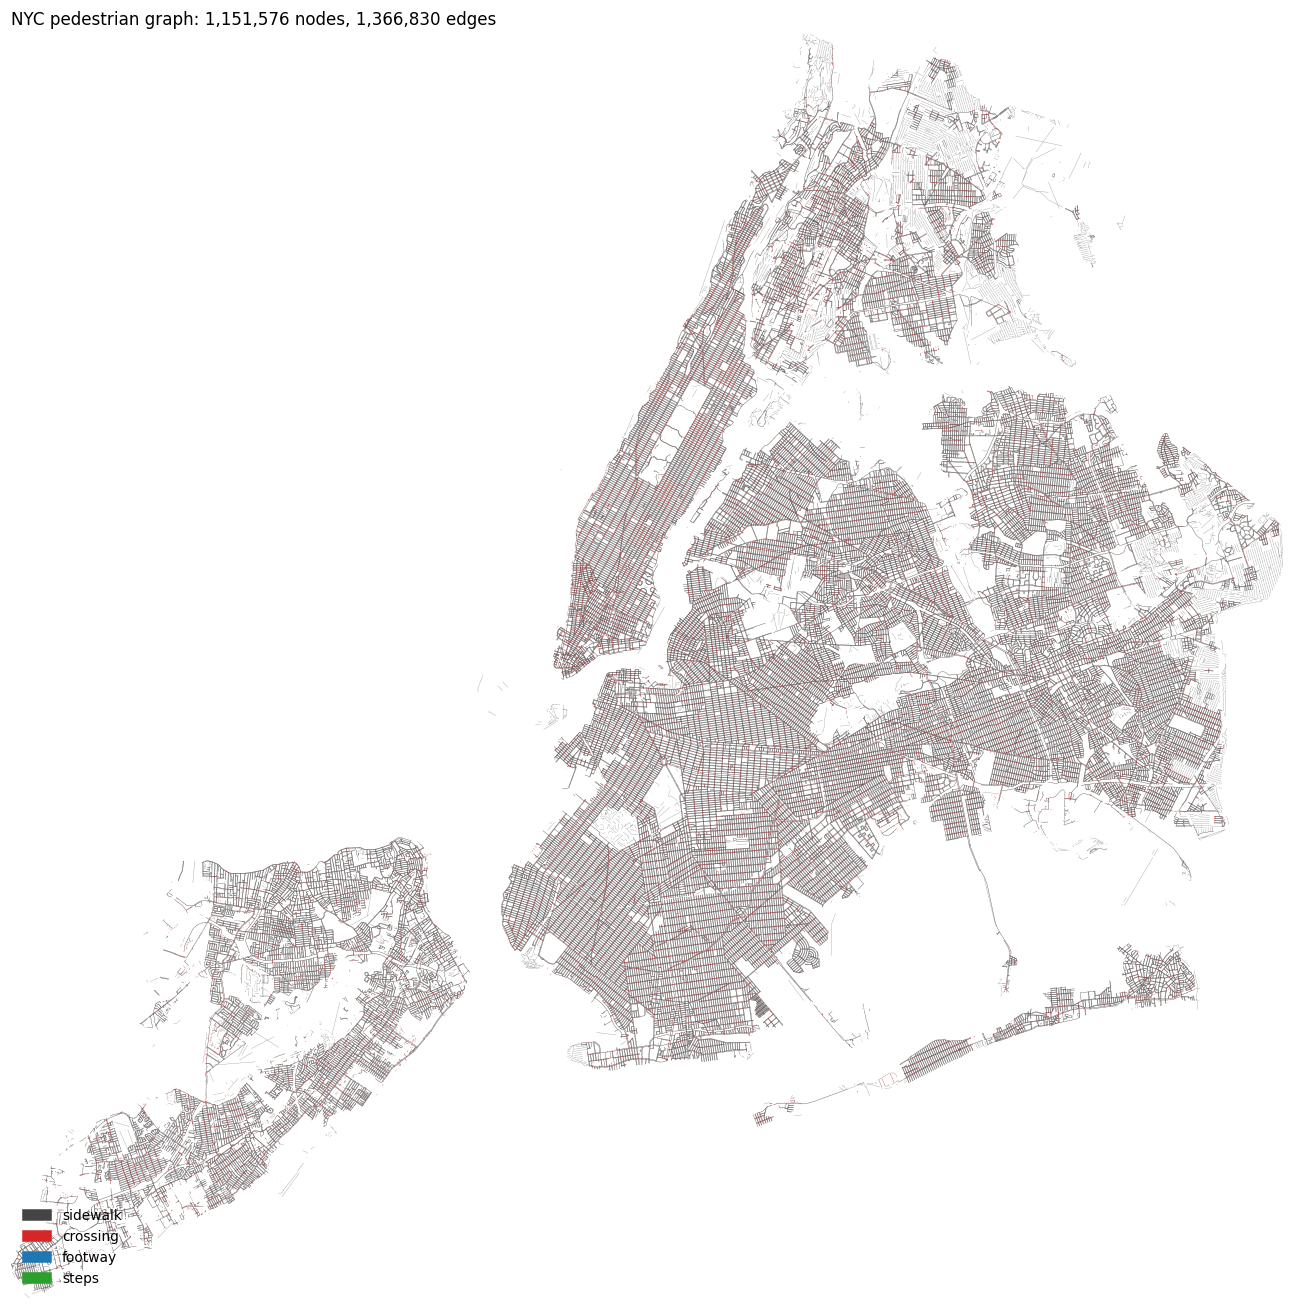

In [13]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.collections import LineCollection

buf = bin_path.read_bytes()
nodes = np.frombuffer(
    buf[16 : 16 + node_count * 10],
    dtype=np.dtype([("lon", "<f4"), ("lat", "<f4"), ("attrs", "u1"), ("pad", "u1")]),
)
edges = np.frombuffer(
    buf[16 + node_count * 10 : 16 + node_count * 10 + edge_count * 18],
    dtype=np.dtype([
        ("u", "<u4"), ("v", "<u4"), ("length", "<f4"),
        ("incline", "<i2"), ("footway", "u1"), ("surface", "u1"),
        ("flags", "u1"), ("width", "u1"),
    ]),
)

segs = np.empty((edge_count, 2, 2), dtype=np.float32)
segs[:, 0, 0] = nodes["lon"][edges["u"]]
segs[:, 0, 1] = nodes["lat"][edges["u"]]
segs[:, 1, 0] = nodes["lon"][edges["v"]]
segs[:, 1, 1] = nodes["lat"][edges["v"]]

CLASS_NAMES  = ["sidewalk", "crossing", "footway", "steps", "other"]
CLASS_COLORS = ["#444444", "#d62728", "#1f77b4", "#2ca02c", "#bbbbbb"]
ftype  = np.clip(edges["footway"], 0, 4)
colors = np.take(CLASS_COLORS, ftype)

fig, ax = plt.subplots(figsize=(12, 12), dpi=110)
lc = LineCollection(segs, colors=colors, linewidths=0.18, alpha=0.7, antialiased=True, rasterized=True)
ax.add_collection(lc)

ax.set_xlim(segs[:, :, 0].min(), segs[:, :, 0].max())
ax.set_ylim(segs[:, :, 1].min(), segs[:, :, 1].max())
ax.set_aspect(1 / np.cos(np.radians(40.71)))   # equirectangular correction at NYC mid-latitude
ax.set_xticks([]); ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

legend = [mpatches.Patch(color=c, label=n) for c, n in zip(CLASS_COLORS[:4], CLASS_NAMES[:4])]
ax.legend(handles=legend, loc="lower left", frameon=False, fontsize=9)
ax.set_title(f"NYC pedestrian graph: {node_count:,} nodes, {edge_count:,} edges",
             fontsize=11, loc="left")
plt.tight_layout()
plt.show()

## Artifacts

| File | Size | Contents | Consumer |
|---|---|---|---|
| `output/nyc.graphml` | 723 MB | Full OSW v0.3 attributed graph as XML | NetworkX, Gephi, igraph, audit |
| `output/nyc-pedestrian.bin` | 34 MB | OSWB v2 packed binary, routing-relevant attributes only | Ariadne in-browser WASM router |